In [153]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.size" : 20,
    "xtick.labelsize" : 20, 
    "ytick.labelsize" : 20,
    #"font.sans-serif": "Helvetica",
})

from scipy.optimize import curve_fit

In [154]:
Ulim,DU = .8, 0.05
Umax = 0.64
U = np.linspace(0, 1, num = 101)

I = lambda U, Ulim : np.ma.masked_less(1 / (1 + np.exp((U-Ulim)/DU)) - 0.5, 0)
P = lambda U, Ulim : I(U, Ulim) * U

In [155]:
I(Umax, Ulim)

masked_array(data=0.46083428,
             mask=False,
       fill_value=1e+20)

<ipython-input-156-9352a3335f55>:10: MatplotlibDeprecationWarning: Case-insensitive properties were deprecated in 3.3 and support will be removed two minor releases later
  ax1.scatter([Umax,], [I(Umax,Ulim)], 200, color = 'black', Zorder = 5)


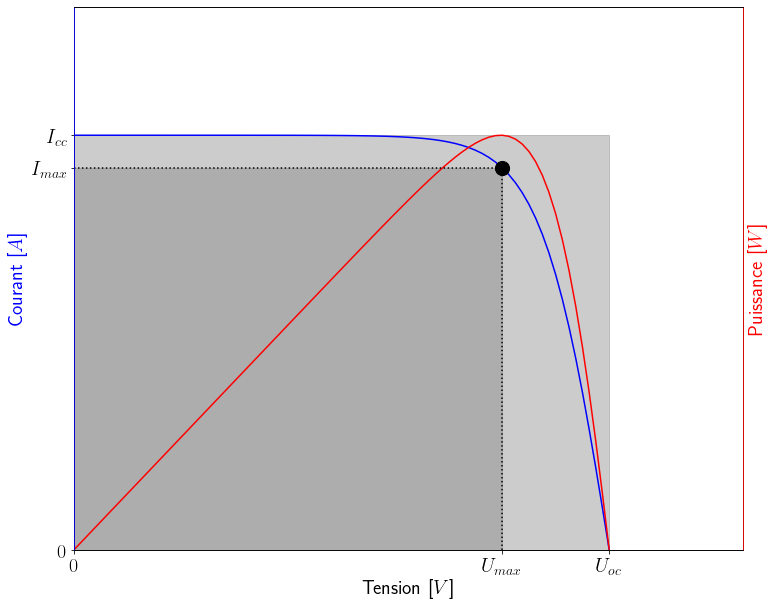

In [156]:
##### plt.style.use('./old-style.mplstyle')

fig1 = plt.figure(figsize=(12,10))
ax1 = fig1.subplots(ncols = 1)
ax2 = ax1.twinx()
#ax1.scatter(U, I(U), edgecolor = 'k', color = 'none', s = 60)#, color = 'red', ls = 'none', marker = 'o')
ax1.plot(U, I(U, Ulim), color = 'blue')
ax1.plot(U, 0.5 / np.max(P(U,Ulim)) * P(U, Ulim), color = 'red')

ax1.scatter([Umax,], [I(Umax,Ulim)], 200, color = 'black', Zorder = 5)


ax1.set_ylabel("Courant [$A$]", color = 'blue')
ax2.set_ylabel("Puissance [$W$]", color = 'red')
ax1.set_xlabel("Tension [$V$]")

ax1.set_xlim(0, 1)
ax1.set_ylim(0,0.655)
#ax2.set_ylim(0,0.33)

ax1.axvspan(xmin = 0, xmax = Ulim, ymin = 0, ymax =  0.5 / ax1.get_ylim()[1], alpha = 0.4, color = "gray")
ax1.axvspan(xmin = 0, xmax = Umax, ymin = 0, ymax =  I(Umax, Ulim) / ax1.get_ylim()[1], alpha = 0.4, color = "gray")
#ax1.axvspan(xmin = 0, xmax = Ulim, ymin = 0, ymax =  0.5 / ax1.get_ylim()[1], alpha = 0.4, color = "gray")

ax1.axvline(x=0.64, ymax = I(Umax, Ulim)/ax1.get_ylim()[1], ls = 'dotted', color = 'black')
ax1.axhline(I(Umax, Ulim), xmax = Umax / ax1.get_xlim()[1], ls = 'dotted', color = 'black')

ax1.set_xticks([0, Umax, Ulim])
ax1.set_xticklabels(['$0$', "$U_{max}$", '$U_{oc}$'])

ax1.set_yticks([0, I(Umax,Ulim), 0.5])
ax1.set_yticklabels(['$0$', "$I_{max}$", '$I_{cc}$'])
ax2.set_yticks([])

ax2.spines['left'].set_color('blue')
ax2.spines['right'].set_color('red')

fig1.savefig("Fig03.pdf", dpi = 200)